<a href="https://colab.research.google.com/github/Keerthanatamma/nasscom/blob/main/Copy_of_Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------
import numpy as np

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


 LAB EXERCISE 1 — Tensor ops: add, transpose, reshape


In [ ]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)
print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')
print("T + T(element-wise add):\n", T + T)
print("T.T(transpose -> shape", T.T.shape, "):\n", T.T)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
tensor  ndim=3  shape=(3, 2, 2)
T + T(element-wise add):
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
T.T(transpose -> shape (4, 3) ):
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


LAB EXERCISE 2 — L1/L2 norms + cosine similarity on 3 vector pairs

In [ ]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    print(f'Pair {i}:')
    print(f'  Vector u: {u}')
    print(f'  L1 norm of u: {la.norm(u, 1):.3f}')
    print(f'  L2 norm of u: {la.norm(u):.3f}')
    print(f'  Vector v: {v}')
    print(f'  L1 norm of v: {la.norm(v, 1):.3f}')
    print(f'  L2 norm of v: {la.norm(v):.3f}')
    # 2. cosine similarity of u and v
    dot_product = np.dot(u, v)
    norm_u = la.norm(u)
    norm_v = la.norm(v)
    cosine_similarity = dot_product / (norm_u * norm_v)
    print(f'  Cosine similarity of u and v: {cosine_similarity:.3f}')
    print('-' * 30)

# 3. Most similar pair = ?   (write your answer here)
# Pair 1 (cosine similarity = 1.000, indicating identical direction)
# Pair 2 (cosine similarity = 0.857)
# Pair 3 (cosine similarity = 0.000, indicating orthogonal vectors)

Pair 1:
  Vector u: [1 0 1]
  L1 norm of u: 2.000
  L2 norm of u: 1.414
  Vector v: [1 0 1]
  L1 norm of v: 2.000
  L2 norm of v: 1.414
  Cosine similarity of u and v: 1.000
------------------------------
Pair 2:
  Vector u: [1 2 3]
  L1 norm of u: 6.000
  L2 norm of u: 3.742
  Vector v: [3 2 1]
  L1 norm of v: 6.000
  L2 norm of v: 3.742
  Cosine similarity of u and v: 0.714
------------------------------
Pair 3:
  Vector u: [2 0 0]
  L1 norm of u: 2.000
  L2 norm of u: 2.000
  Vector v: [0 5 0]
  L1 norm of v: 5.000
  L2 norm of v: 5.000
  Cosine similarity of u and v: 0.000
------------------------------


🧪 LAB EXERCISE 3 — Inverse, trace, and matrix tests

In [ ]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])
print('Inverse of M:\n', la.inv(M))
print('Trace of M:', np.trace(M))
I = np.eye(M.shape[0]) # Define I as the identity matrix with dimensions matching M
print('M @ inv(M) == I ?', np.allclose(M @ la.inv(M), I))
print ('M symmetric ? ', np.allclose(M,M.T))

print('P orthogonal?', np.allclose(P.T @ P, I))

Inverse of M:
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace of M: 7.0
M @ inv(M) == I ? True
M symmetric ?  True
P orthogonal? True


In [ ]:


# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)



Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


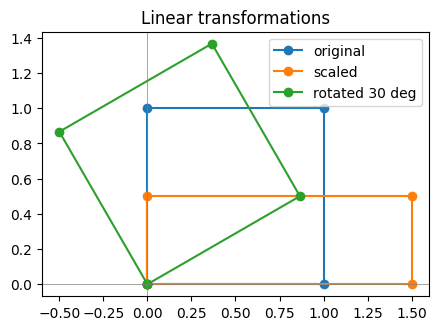

In [ ]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

AB EXERCISE 4 — Apply 2 transformations & plot

Rotated corners:
 [[ 0.     0.707 -0.354]
 [ 0.     0.707  1.061]]


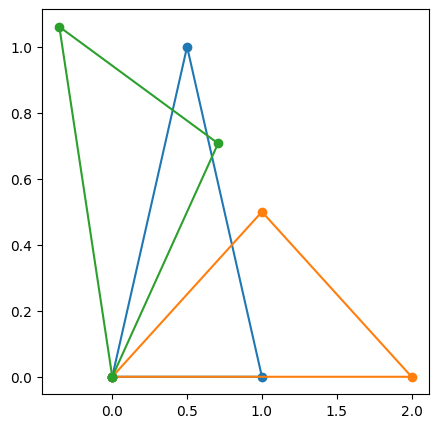

In [ ]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])
S = np.array([[2, 0], [0,0.5]])
t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])
scaled  = S @ tri      # apply scaling
rotated = R @ tri      # apply rotation
print('Rotated corners:\n', rotated)

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(*close_loop(tri),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 45 deg')

plt.show()



In [ ]:


# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)



Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


In [ ]:
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))



lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


 LAB EXERCISE 5 — Eigenvalues/vectors & verification

In [ ]:
C = np.array([[4., 1.],
              [2., 3.]])
vals,vecs = la.eig(C)
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

v = vecs[:, 0]      # first eigenvector

print("Is C @ v = lambda*v?",  np.allclose(C @ v, vals[0] * v))

Eigenvalues  (lambda): [5. 2.]
Eigenvectors (columns):
 [[ 0.707 -0.447]
 [ 0.707  0.894]]
Is C @ v = lambda*v? True


In [ ]:
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')



Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [ ]:
# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')


Rank of D: 2 -> < 3, so rows are dependent


In [ ]:
from scipy.spatial.distance import cosine


# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low


cosine(king, queen): 0.014
cosine(king, apple): 0.733


 LAB EXERCISE 6 — Solve a system + compare embeddings

In [ ]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])
x = la.solve(A2, b2)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A2 :', la.matrix_rank(A2))
print('cosine(cat, dog):', round(cosine(cat, dog),3))
print('cosine(cat, car):', round(cosine(cat, car),3 ))

Solution x: [1. 2.]
Rank of A2 : 2
cosine(cat, dog): 0.005
cosine(cat, car): 0.707


In [ ]:
# Core imports for the whole lab
import numpy as np
import sympy as sp

x, y = sp.symbols('x y')      # symbolic variables we'll reuse
sp.init_printing()            # pretty-print symbolic math
np.random.seed(42)
print('Setup complete. SymPy', sp.__version__, '| NumPy', np.__version__)

Setup complete. SymPy 1.14.0 | NumPy 2.0.2


In [ ]:


# -----------------------------------------------------------
# 🔹 1A. NUMERICAL DERIVATIVE (finite difference)
# -----------------------------------------------------------

# The derivative is the slope: how much f changes for a tiny step h
def f(x):
    return x**2

h = 1e-6       # i.e, 1*10^-6
slope_at_3 = (f(3 + h) - f(3)) / h
print('Numerical f\'(3):', round(slope_at_3, 4), ' (exact = 6)')

# -----------------------------------------------------------
# 🔹 1B. SYMBOLIC DERIVATIVE (SymPy)
# -----------------------------------------------------------

# Re-declare x as a symbolic variable specifically for this section
# to avoid conflict with the numpy array 'x' defined elsewhere.
x = sp.symbols('x')

expr = x**2
deriv = sp.diff(expr, x)          # differentiate w.r.t. x
print('d/dx (x**2) =', deriv)     # 2*x

# Evaluate the symbolic derivative at x = 3
print('Symbolic f\'(3) =', deriv.subs(x, 3))


Numerical f'(3): 6.0  (exact = 6)
d/dx (x**2) = 2*x
Symbolic f'(3) = 6


In [ ]:

def g(x):
    return x**3 + 2*x
h = 1e-6
slope_at_2 = (f(2 + h) - f(2)) / h      # slope formulae= (f(x+h) - f(x))/h
print('Numerical f\'(2):', round(slope_at_2))
x = sp.symbols('x')

expr = x**3 + 2*x
deriv = sp.diff(expr, x)
print('d/dx (x**3 + 2*x) =', deriv)
print('symbolic f\'(2)=', deriv.subs(x, 2))

Numerical f'(2): 4
d/dx (x**3 + 2*x) = 3*x**2 + 2
symbolic f'(2)= 14


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. PARTIAL DERIVATIVES
# -----------------------------------------------------------

f2 = x**2 + 3*x*y + y**2

# A partial derivative differentiates ONE variable, holding others fixed
print('df/dx =', sp.diff(f2, x))     # 2*x + 3*y
print('df/dy =', sp.diff(f2, y))     # 3*x + 2*y


# -----------------------------------------------------------
# 🔹 2B. THE GRADIENT (vector of partials)
# -----------------------------------------------------------

# The gradient stacks every partial derivative into one vector
grad = [sp.diff(f2, v) for v in (x, y)]
print('grad f =', grad)

# Evaluate the gradient at the point (x=1, y=2)
grad_at = [g.subs({x: 1, y: 2}) for g in grad]
print('grad f at (1, 2) =', grad_at)   # points in the steepest-ascent direction



df/dx = 2*x + 3*y
df/dy = 3*x + 2*y
grad f = [2*x + 3*y, 3*x + 2*y]
grad f at (1, 2) = [8, 7]


In [ ]:
h2 = x**2 * y + sp.sin(y)
print('dh/dx =', sp.diff(h2, x))
print('dh/dy =', sp.diff(h2, y))
grad = [sp.diff(h2, v) for v in (x, y)]
print('grad h =', grad)
grad_at = [g.subs({x: 2, y:0}) for g in grad]
print('grad h at (2, 0) =', grad_at)

dh/dx = 2*x*y
dh/dy = x**2 + cos(y)
grad h = [2*x*y, x**2 + cos(y)]
grad h at (2, 0) = [0, 5]


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. CHAIN RULE BY HAND vs SymPy
# -----------------------------------------------------------

# y = sin(x**2) is a composition: outer = sin(u), inner = u = x**2
# Chain rule:  dy/dx = cos(u) * du/dx = cos(x**2) * 2x
by_hand = sp.cos(x**2) * 2*x
by_sympy = sp.diff(sp.sin(x**2), x)

print('By hand :', by_hand)
print('By SymPy:', by_sympy)
print('Match?  ', sp.simplify(by_hand - by_sympy) == 0)


# -----------------------------------------------------------
# 🔹 3B. CHAINING THREE FUNCTIONS
# -----------------------------------------------------------

# y = (3x + 1)**4  -> outer^4, inner (3x+1)
expr3 = (3*x + 1)**4
print('d/dx (3x+1)^4 =', sp.diff(expr3, x))   # 12*(3x+1)^3



By hand : 2*x*cos(x**2)
By SymPy: 2*x*cos(x**2)
Match?   True
d/dx (3x+1)^4 = 12*(3*x + 1)**3


In [ ]:
# y = exp(x**2 + 1);  inner = x**2 + 1, inner' = 2x, outer' = exp(inner)
by_hand = sp.exp(x**2 + 1) * 2*x
by_sympy = sp.diff(sp.exp(x**2 + 1), x)

print('By hand :', by_hand)
print('By SymPy:', by_sympy)
print('Match?  ', sp.simplify(by_hand - by_sympy) == 0)


By hand : 2*x*exp(x**2 + 1)
By SymPy: 2*x*exp(x**2 + 1)
Match?   True


In [ ]:
from sys import dont_write_bytecode
Xb = np.random.randn(6, 4)
Yb = np.random.randn(6, 1)
Wa = np.random.randn(4, 8) * 0.1     # input -> hidden
Wb = np.random.randn(8, 1) * 0.1     # hidden -> output
z1 = Xb @ Wa                 # linear layer 1
h  = np.maximum(0, z1)      # ReLU activation
y_hat = h @ Wb              # linear layer 2 (prediction)
loss = ((y_hat - Yb) ** 2).mean()
print('Initial loss:', round(loss, 4))

dy   = 2 * (y_hat - Yb) / Yb.size      # d loss / d y_hat
dWb  = h.T @ dy                      # d loss / d W2
dh   = dy @ Wb.T                     # d loss / d h
dz1  = dh * (z1 > 0)                 # ReLU gradient (1 where z1>0 else 0)
dWa  = Xb.T @ dz1                     # d loss / d W1

print('dWa shape:', dWa.shape, '(matches Wa)')
print('dWb shape:', dWb.shape, '(matches Wb)')

lr = 0.05
Wa -= lr * dWa               # step downhill
Wb -= lr * dWb

h_new = np.maximum(0, Xb @ Wa)
loss_new = ((h_new @ Wb - Yb) ** 2).mean()
print('Loss before:', round(loss, 4))
print('Loss after :', round(loss_new, 4), '-> should be lower')

Initial loss: 1.1045
dWa shape: (4, 8) (matches Wa)
dWb shape: (8, 1) (matches Wb)
Loss before: 1.1045
Loss after : 1.0892 -> should be lower


In [ ]:
Xb = np.random.randn(6, 4)
Yb = np.random.randn(6, 1)
Wa = np.random.randn(4, 8) * 0.1     # input -> hidden
Wb = np.random.randn(8, 1) * 0.1     # hidden -> output

# 1. Forward pass: z1, h = ReLU(z1), y_hat, loss
# YOUR CODE HERE
# Tiny toy problem: 4 samples, 3 input features, 5 hidden units, 1 output


z1 = Xb @ Wa                 # linear layer 1
h  = np.maximum(0, z1)      # ReLU activation
y_hat = h @ Wb              # linear layer 2 (prediction)
loss = ((y_hat - Yb) ** 2).mean()
print('Initial loss:', round(loss, 4))
# 2. Backward pass: dy, dWb, dh, dz1, dWa
# YOUR CODE HERE
dy   = 2 * (y_hat - Yb) / Yb.size      # d loss / d y_hat
dWb  = h.T @ dy                      # d loss / d W2
dh   = dy @ Wb.T                     # d loss / d h
dz1  = dh * (z1 > 0)                 # ReLU gradient (1 where z1>0 else 0)
dWa  = Xb.T @ dz1                     # d loss / d W1

print('dW1 shape:', dW1.shape, '(matches Wa)')
print('dW2 shape:', dW2.shape, '(matches Wb)')
# 3. One step with lr = 0.05; print loss before and after
# YOUR CODE HERE
lr = 0.05
Wa -= lr * dWa              # step downhill
Wb -= lr * dWb

# Recompute the loss after the update
h_new = np.maximum(0, Xb @ Wa)
loss_new = ((h_new @ Wb - Yb) ** 2).mean()
print('Loss before:', round(loss, 4))
print('Loss after :', round(loss_new, 4), '-> should be lower')

Initial loss: 1.1691
dW1 shape: (4, 8) (matches Wa)
dW2 shape: (8, 1) (matches Wb)
Loss before: 1.1691
Loss after : 1.1571 -> should be lower


In [ ]:
f = x**4 + y**2
H = sp.hessian(f, (x, y))
print('Hessian of f:')
sp.pprint(H)        # [[2, 3], [3, 2]]


#Gradient descent to minimise (x - 7)**2
xv = 0.0          # starting point
lr = 0.1
for step in range(20):
    grad = 2 * (xv - 7)        # the derivative
    xv = xv - lr * grad        # step against the gradient
print('Converged x:', round(xv, 3), ' (true minimum = 4)')

Hessian of f:
⎡    2   ⎤
⎢12⋅x   0⎥
⎢        ⎥
⎣  0    2⎦
Converged x: 6.919  (true minimum = 4)
Hessian of f:
⎡    2   ⎤
⎢12⋅x   0⎥
⎢        ⎥
⎣  0    2⎦
Converged x: 6.919  (true minimum = 4)


In [ ]:


import numpy as np

print("--- Intermediate NumPy Exercise ---")
print("Complete each task by writing the requested NumPy code.")
print("-----------------------------------")

# Task 1: Array Creation Shortcuts
print("\n--- Task 1: Array Creation Shortcuts ---")
# 1.1 Create a 1D array named 'arr1_1' with numbers from 0 to 99 (inclusive) using arange.
# 1.2 Create a 3x3 array named 'arr1_2' filled with ones.
# 1.3 Create a 2x4 array named 'arr1_3' filled with the number 7.
# 1.4 Create a 5x5 array named 'arr1_4' with random integers between 10 and 50 (inclusive).

# Your code for Task 1 here:
arr1_1 = np.arange(100)
arr1_2 = np.ones((3, 3))
arr1_3 = np.full((2, 4), 7)
arr1_4 = np.random.randint(10, 51, size=(5, 5))

print("arr1_1 (first 10 elements):", arr1_1[:10])
print("arr1_2:\n", arr1_2)
print("arr1_3:\n", arr1_3)
print("arr1_4 (first 2 rows):\n", arr1_4[:2])


# Task 2: Indexing and Slicing with Arrays
print("\n--- Task 2: Indexing and Slicing with Arrays ---")
data = np.array([[10, 20, 30, 40],
                 [50, 60, 70, 80],
                 [90, 100, 110, 120],
                 [130, 140, 150, 160]])

# 2.1 Extract the element at row 2, column 3 (0-indexed). Store it in 'val2_1'.
# 2.2 Extract the first row. Store it in 'row2_2'.
# 2.3 Extract the last column. Store it in 'col2_3'.
# 2.4 Extract the sub-array consisting of rows 1 and 2, and columns 0 and 1. Store it in 'sub_arr2_4'.
# 2.5 Using boolean indexing, select all elements in 'data' that are greater than 100. Store them in 'filtered_elements2_5'.

# Your code for Task 2 here:
val2_1 = data[2, 3]
row2_2 = data[0, :]
col2_3 = data[:, -1]
sub_arr2_4 = data[1:3, 0:2]
filtered_elements2_5 = data[data > 100]


# Task 3: Conditional Operations
print("\n--- Task 3: Conditional Operations ---")
arr3_1 = np.random.randint(1, 21, size=(4, 5)) # Random 4x5 array with values 1 to 20

# 3.1 Create a new array 'arr3_2' where elements in 'arr3_1' less than 10 are replaced with 0,
#     and elements greater than or equal to 10 remain unchanged.
# 3.2 Count how many elements in 'arr3_1' are even. Store the count in 'even_count3_3'.

# Your code for Task 3 here:
arr3_2 = np.where(arr3_1 < 10, 0, arr3_1)
even_count3_3 = np.sum(arr3_1 % 2 == 0)


# Task 4: Aggregation Functions
print("\n--- Task 4: Aggregation Functions ---")
arr4_1 = np.array([[10, 5, 12],
                   [3, 8, 15],
                   [20, 7, 4]])

# 4.1 Calculate the sum of all elements in 'arr4_1'. Store it in 'sum4_1'.
# 4.2 Calculate the mean of each column. Store it in 'mean_cols4_2'.
# 4.3 Find the maximum value in each row. Store it in 'max_rows4_3'.
# 4.4 Calculate the standard deviation of the entire array. Store it in 'std4_4'.

# Your code for Task 4 here:
sum4_1 = np.sum(arr4_1)
mean_cols4_2 = np.mean(arr4_1, axis=0)
max_rows4_3 = np.max(arr4_1, axis=1)
std4_4 = np.std(arr4_1)


# Task 5: Reshaping and Flattening
print("\n--- Task 5: Reshaping and Flattening ---")
arr5_1 = np.arange(24) # 1D array from 0 to 23

# 5.1 Reshape 'arr5_1' into a 4x6 2D array. Store it in 'reshaped_arr5_2'.
# 5.2 Reshape 'arr5_1' into a 2x3x4 3D array. Store it in 'reshaped_arr5_3'.
# 5.3 Flatten 'reshaped_arr5_2' back into a 1D array. Store it in 'flattened_arr5_4'.
#     Use both `.ravel()` and `.flatten()` to see if there's a difference (though not visible in output).

# Your code for Task 5 here:
reshaped_arr5_2 = arr5_1.reshape(4, 6)
reshaped_arr5_3 = arr5_1.reshape(2, 3, 4)
flattened_arr5_4_ravel = reshaped_arr5_2.ravel()
flattened_arr5_4_flatten = reshaped_arr5_2.flatten()
flattened_arr5_4 = flattened_arr5_4_flatten # Assign one of them for the variable


# Task 6: Broadcasting
print("\n--- Task 6: Broadcasting ---")
arr6_1 = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
scalar = 10
vector = np.array([100, 200, 300])

# 6.1 Add the 'scalar' to every element of 'arr6_1'. Store it in 'result6_1'.
# 6.2 Add the 'vector' to each row of 'arr6_1'. Store it in 'result6_2'.

# Your code for Task 6 here:
result6_1 = arr6_1 + scalar
result6_2 = arr6_1 + vector


# Task 7: Copying vs. Viewing Arrays
print("\n--- Task 7: Copying vs. Viewing Arrays ---")
original_arr7 = np.array([1, 2, 3, 4, 5])

# 7.1 Create a 'view' of 'original_arr7' named 'view_arr7' by slicing the entire array.
#     Modify the first element of 'view_arr7' to 99.
#     Observe how 'original_arr7' changes.
# 7.2 Create a 'copy' of 'original_arr7' named 'copy_arr7' using `.copy()`.
#     Modify the last element of 'copy_arr7' to 0.
#     Observe how 'original_arr7' remains unchanged.

# Your code for Task 7 here:
view_arr7 = original_arr7[:]
view_arr7[0] = 99

copy_arr7 = original_arr7.copy()
copy_arr7[-1] = 0


# Task 8: Stacking and Splitting Arrays
print("\n--- Task 8: Stacking and Splitting Arrays ---")
arr8_a = np.array([[1, 2], [3, 4]])
arr8_b = np.array([[5, 6], [7, 8]])
arr8_c = np.array([[9, 10]])

# 8.1 Vertically stack 'arr8_a' and 'arr8_b'. Store it in 'vstack_arr8_1'.
# 8.2 Horizontally stack 'arr8_a' and 'arr8_b'. Store it in 'hstack_arr8_2'.
# 8.3 Vertically stack 'vstack_arr8_1' and 'arr8_c'. Store it in 'combined_arr8_3'.
# 8.4 Split 'combined_arr8_3' into 3 equal parts (rows). Store them in 'part1', 'part2', 'part3'.

# Your code for Task 8 here:
vstack_arr8_1 = np.vstack((arr8_a, arr8_b))
hstack_arr8_2 = np.hstack((arr8_a, arr8_b))
combined_arr8_3 = np.vstack((vstack_arr8_1, arr8_c))
part1, part2, part3 = np.vsplit(combined_arr8_3, 3)


# Task 9: Sorting and Searching
print("\n--- Task 9: Sorting and Searching ---")
arr9_1 = np.array([5, 2, 8, 1, 9, 4, 7, 3, 6])
arr9_2d = np.array([[30, 20, 10],
                    [60, 50, 40],
                    [90, 80, 70]])

# 9.1 Sort 'arr9_1' in ascending order. Store it in 'sorted_arr9_1'.
# 9.2 Sort 'arr9_2d' along columns (i.e., each column sorted independently). Store it in 'sorted_cols9_2'.
# 9.3 Find the indices where the value 9 is present in 'arr9_1'. Store it in 'idx9_3'. (Hint: use np.where)
# 9.4 Find the index of the maximum value in 'arr9_1'. Store it in 'max_idx9_4'.

# Your code for Task 9 here:
sorted_arr9_1 = np.sort(arr9_1)
sorted_cols9_2 = np.sort(arr9_2d, axis=0)
idx9_3 = np.where(arr9_1 == 9)
max_idx9_4 = np.argmax(arr9_1)




--- Intermediate NumPy Exercise ---
Complete each task by writing the requested NumPy code.
-----------------------------------

--- Task 1: Array Creation Shortcuts ---
arr1_1 (first 10 elements): [0 1 2 3 4 5 6 7 8 9]
arr1_2:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
arr1_3:
 [[7 7 7 7]
 [7 7 7 7]]
arr1_4 (first 2 rows):
 [[30 26 31 46 24]
 [44 37 16 41 20]]

--- Task 2: Indexing and Slicing with Arrays ---

--- Task 3: Conditional Operations ---

--- Task 4: Aggregation Functions ---

--- Task 5: Reshaping and Flattening ---

--- Task 6: Broadcasting ---

--- Task 7: Copying vs. Viewing Arrays ---

--- Task 8: Stacking and Splitting Arrays ---

--- Task 9: Sorting and Searching ---
